Task 2 - Lasso & Ridge Regression

1.	Use the Boston Housing dataset (or any dataset with numerical predictors).

2.	Apply Lasso Regression and tune the regularization parameter α using cross-validation.

3.	Identify which features get reduced to zero.

4.	Apply Ridge Regression to the same dataset.

5.	Compare the coefficients with those from Lasso and Linear Regression.

6.	Discuss how Ridge helps in reducing overfitting.

7.	Plot the change in coefficients as α increases for both Lasso and Ridge Regression.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.linear_model import Lasso,Ridge,LassoCV,RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error
import math


In [ ]:
## 1.	Use the Boston Housing dataset 
boston = fetch_openml(name="boston", version=1)
data = pd.DataFrame(boston.data,columns=boston.feature_names)
data['Price'] = boston.target
from sklearn.model_selection import train_test_split
x = data.drop('Price', axis=1)
y = data['Price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =0.2,
                                                    random_state = 0)
x_test = x_test.apply(pd.to_numeric, errors='coerce')
x_train = x_train.apply(pd.to_numeric, errors='coerce')
data.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


CRIM       -0.119443
ZN          0.044780
INDUS       0.005485
CHAS        2.340804
NOX       -16.123604
RM          3.708709
AGE        -0.003121
DIS        -1.386397
RAD         0.244178
TAX        -0.010990
PTRATIO    -1.045921
B           0.008110
LSTAT      -0.492793
dtype: float64


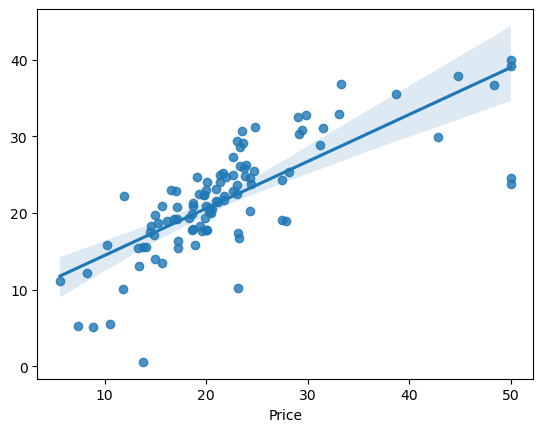

In [ ]:
## LInear regression Model and evalution metrics

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

linear_coefs = pd.Series(model.coef_, index=x_train.columns)
print(linear_coefs)
sns.regplot(x=y_test,y=model.predict(x_test))
linear_r2 = r2_score(y_test, model.predict(x_test))
linear_mse_r2 = mean_squared_error(y_test, model.predict(x_test))
linear_mae_r2 = mean_absolute_error(y_test, model.predict(x_test))
linear_msre = math.sqrt(mean_squared_error(y_test, model.predict(x_test)))


In [ ]:
# #Apply Lasso Regression and tune the regularization parameter α using cross-validation.

## lasso find  best alpha (range is 0.1 to 1)
lasso_cv = LassoCV(alphas=np.arange(0.1, 1, 0.1), cv=5, random_state=42)
lasso_cv.fit(x_train, y_train)

print("Best alpha fot Lasso:", lasso_cv.alpha_)

lasso_r2 = r2_score(y_test, lasso_cv.predict(x_test))
lasso_mse_r2 = mean_squared_error(y_test, lasso_cv.predict(x_test))
lasso_mae_r2 = mean_absolute_error(y_test, lasso_cv.predict(x_test))
lasso_msre = math.sqrt(mean_squared_error(y_test, lasso_cv.predict(x_test)))


Best alpha fot Lasso: 0.2


 lasso coefficients:
CRIM      -0.107098
ZN         0.048578
INDUS     -0.033596
CHAS       0.000000
NOX       -0.000000
RM         3.287921
AGE       -0.009908
DIS       -1.060160
RAD        0.213099
TAX       -0.013402
PTRATIO   -0.898520
B          0.009027
LSTAT     -0.550208
dtype: float64

Features reduced to zero by Lasso:
['CHAS', 'NOX']


<Axes: xlabel='Price'>

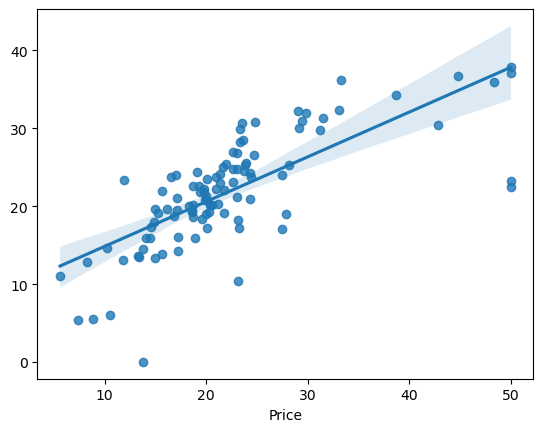

In [ ]:
#  Identify which features get reduced to zero.
lasso_coefs = pd.Series(lasso_cv.coef_, index=x_train.columns)

print(" lasso coefficients:")
print(lasso_coefs)

# find Features with zero coefficients value
zero_value_feature = lasso_coefs[lasso_coefs == 0].index.tolist()
print("\nFeatures reduced to zero by Lasso:")
print(zero_value_feature)
sns.regplot(x=y_test,y=lasso_cv.predict(x_test))


best  alpha  for Ridge : 0.1
CRIM       -0.118983
ZN          0.044977
INDUS       0.000411
CHAS        2.336109
NOX       -14.812614
RM          3.719342
AGE        -0.004407
DIS        -1.367900
RAD         0.240226
TAX        -0.011077
PTRATIO    -1.032485
B           0.008184
LSTAT      -0.493652
dtype: float64


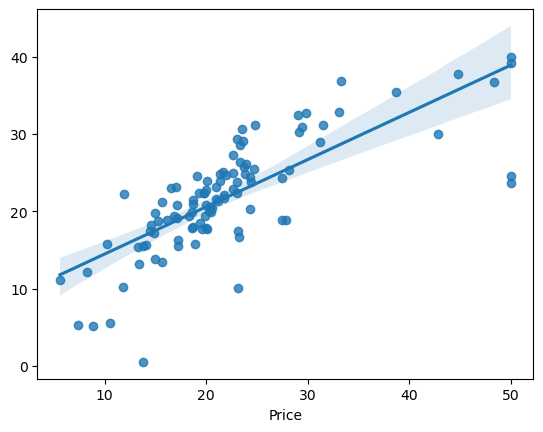

In [ ]:
ridge_cv = RidgeCV(alphas=np.arange(0.1, 1, 0.1), cv=5)
ridge_cv.fit(x_train, y_train)

print("best  alpha  for Ridge :", ridge_cv.alpha_)

ridge_coefs = pd.Series(ridge_cv.coef_, index=x_train.columns)
print(ridge_coefs)
sns.regplot(x=y_test,y=ridge_cv.predict(x_test))
ridge_r2 = r2_score(y_test, ridge_cv.predict(x_test))
ridge_mse_r2 = mean_squared_error(y_test, ridge_cv.predict(x_test))
ridge_mae_r2 = mean_absolute_error(y_test, ridge_cv.predict(x_test))
ridge_msre = math.sqrt(mean_squared_error(y_test, ridge_cv.predict(x_test)))



Coefficient Comparison:
            Linear     Lasso      Ridge
CRIM     -0.119443 -0.107098  -0.118983
ZN        0.044780  0.048578   0.044977
INDUS     0.005485 -0.033596   0.000411
CHAS      2.340804  0.000000   2.336109
NOX     -16.123604 -0.000000 -14.812614
RM        3.708709  3.287921   3.719342
AGE      -0.003121 -0.009908  -0.004407
DIS      -1.386397 -1.060160  -1.367900
RAD       0.244178  0.213099   0.240226
TAX      -0.010990 -0.013402  -0.011077
PTRATIO  -1.045921 -0.898520  -1.032485
B         0.008110  0.009027   0.008184
LSTAT    -0.492793 -0.550208  -0.493652
   Linear[r2,mse,mae,rmse]  lasso[r2,mse,mae,rmse]  ridge[r2,mse,mae,rmse]
0                 0.589222                0.551105                0.588000
1                33.448980               36.552835               33.548488
2                 3.842909                3.944029                3.839017
3                 5.783509                6.045894                5.792106


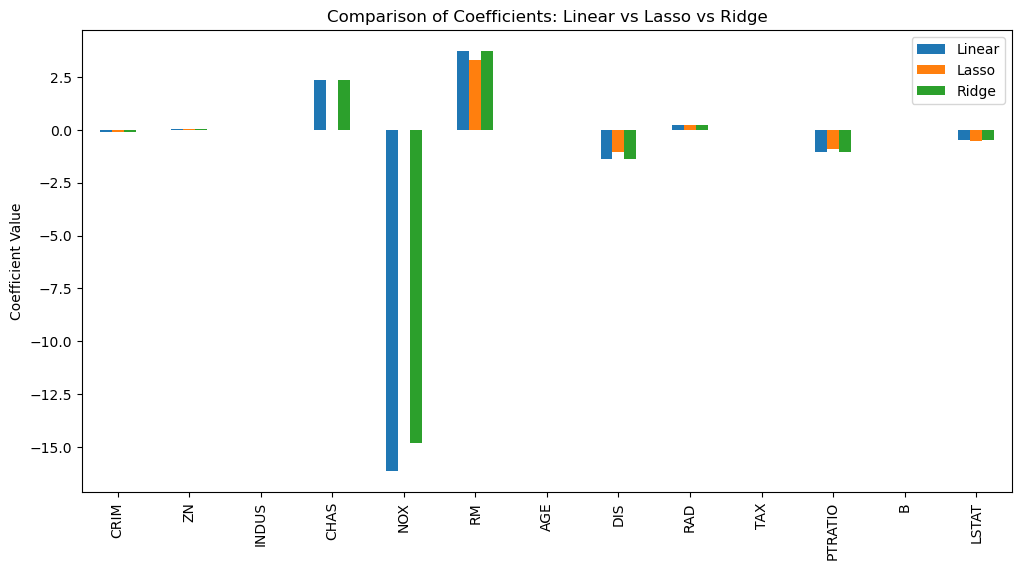

In [ ]:
# Linear Regression (no regularization)
linear = LinearRegression()
linear.fit(x_train, y_train)
linear_coefs = pd.Series(linear.coef_, index=x_train.columns)

## Compare the coefficients with those from Lasso and Linear Regression.

coef_df = pd.DataFrame({
    "Linear": linear_coefs,
    "Lasso": lasso_coefs,
    "Ridge": ridge_coefs,
   
    
})
evalution =  pd.DataFrame({
 'Linear[r2,mse,mae,rmse]' : [linear_r2,linear_mse_r2,linear_mae_r2,linear_msre],
    'Lasso[r2,mse,mae,rmse]' : [lasso_r2,lasso_mse_r2,lasso_mae_r2,lasso_msre],
    'Ridge[r2,mse,mae,rmse]' : [ridge_r2,ridge_mse_r2,ridge_mae_r2,ridge_msre]
})


linear_r2 = r2_score(y_test, model.predict(x_test))
linear_mse_r2 = mean_squared_error(y_test, model.predict(x_test))
linear_mae_r2 = mean_absolute_error(y_test, model.predict(x_test))
linear_msre
print("\n\n\ncoefficient comparison:")
print(coef_df)
print(evalution)

# Plot comparison
coef_df.plot(kind='bar', figsize=(12,6))
plt.title("Comparison of Coefficients: Linear vs Lasso vs Ridge")
plt.ylabel("Coefficient Value")
plt.show()


## Discuss how Ridge helps in reducing overfitting.
--> in Ridge it add square of coeeficient so if coeeficient value is too large then it squre is even large 
and 
--> Ridge regression adds a small penalty to the model when the coefficient values become too large.This penalty is based on the sum of the squares of the coefficients that’s what the termλ × (sum of all coefficient squares) means.

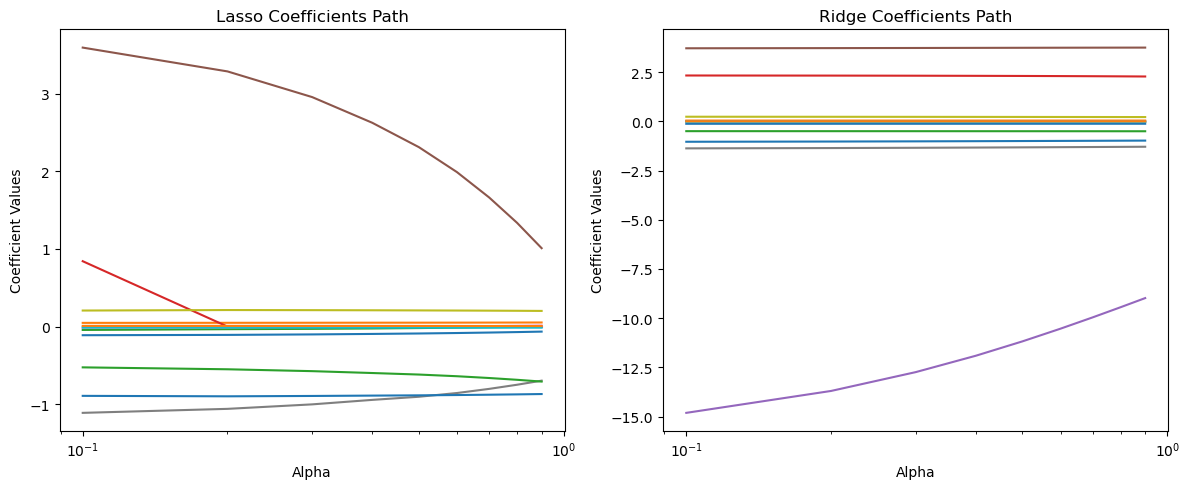

In [ ]:
alphas = np.arange(0.1, 1, 0.1)
lasso_coefs_path = []
ridge_coefs_path = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    ridge = Ridge(alpha=a)
    lasso.fit(x_train, y_train)
    ridge.fit(x_train, y_train)
    lasso_coefs_path.append(lasso.coef_)
    ridge_coefs_path.append(ridge.coef_)

plt.figure(figsize=(12,5))

# Lasso Path
plt.subplot(1,2,1)
plt.plot(alphas, np.array(lasso_coefs_path))
plt.xscale('log')
plt.title("Lasso Coefficients Path")
plt.xlabel("Alpha")
plt.ylabel("Coefficient Values")

# Ridge Path
plt.subplot(1,2,2)
plt.plot(alphas, np.array(ridge_coefs_path))
plt.xscale('log')
plt.title("Ridge Coefficients Path")
plt.xlabel("Alpha")
plt.ylabel("Coefficient Values")

plt.tight_layout()
plt.show()
